In [2]:
import sys
!{sys.executable} -m pip install pandas polars matplotlib seaborn tqdm ipykernel

In [6]:
# data loading 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
df = pd.read_csv('../data/raw/complaints.csv', low_memory=False)
print(f"Dataset Loaded: {len(df)} rows")
df.head()

Dataset Loaded: 9609797 rows


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


C:\Users\Betty\AppData\Local\Temp\ipykernel_5944\3089890309.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=narrative_counts.index, y=narrative_counts.values, palette='viridis')


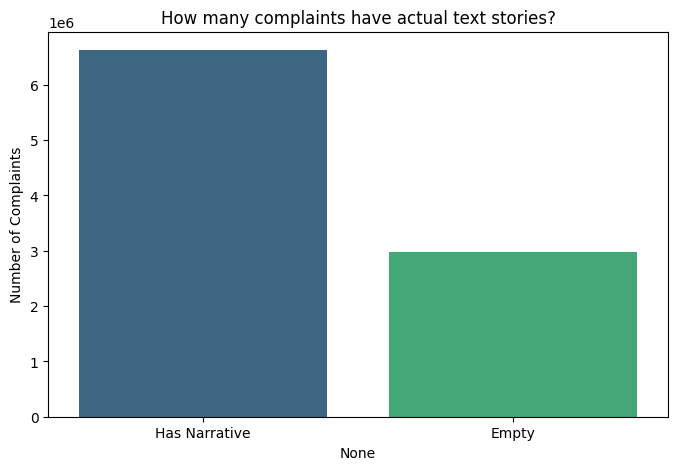

In [7]:
# Narrative Presence (Task: Count complaints with/without narratives)
# Count how many have text vs how many are empty
narrative_counts = df['Consumer complaint narrative'].isna().value_counts()
narrative_counts.index = ['Has Narrative', 'Empty']

plt.figure(figsize=(8, 5))
sns.barplot(x=narrative_counts.index, y=narrative_counts.values, palette='viridis')
plt.title('How many complaints have actual text stories?')
plt.ylabel('Number of Complaints')
plt.show()

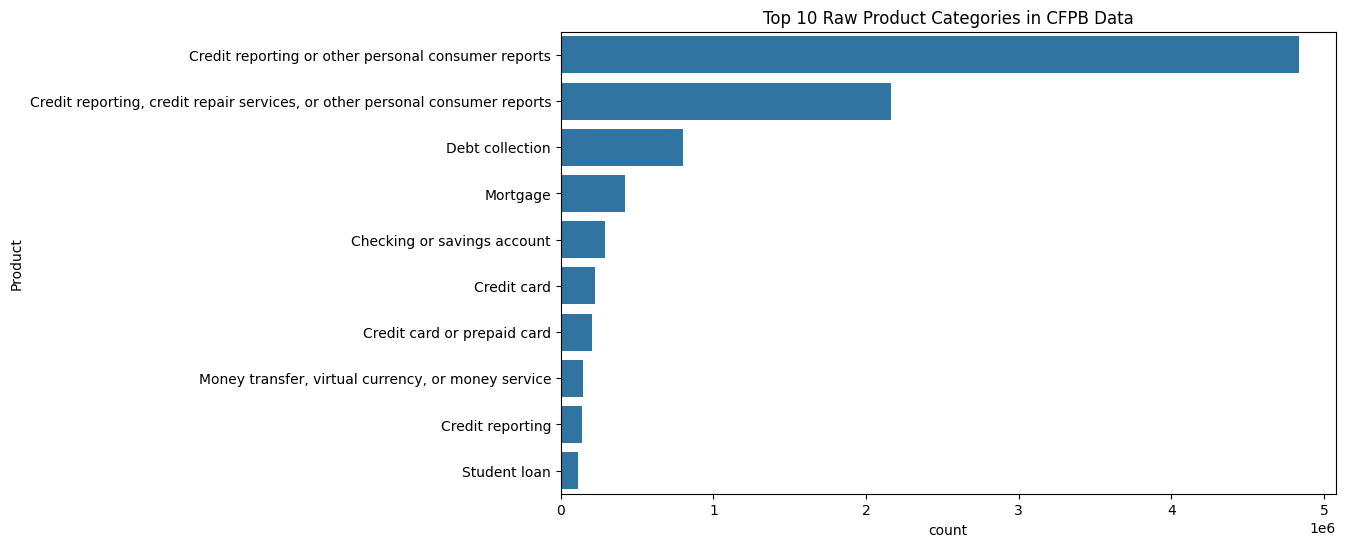

In [8]:
# Product Distribution (Task: Analyze distribution across products)
plt.figure(figsize=(10, 6))
# Focus on the top 10 most common products
sns.countplot(y='Product', data=df, order=df['Product'].value_counts().iloc[:10].index)
plt.title('Top 10 Raw Product Categories in CFPB Data')
plt.show()

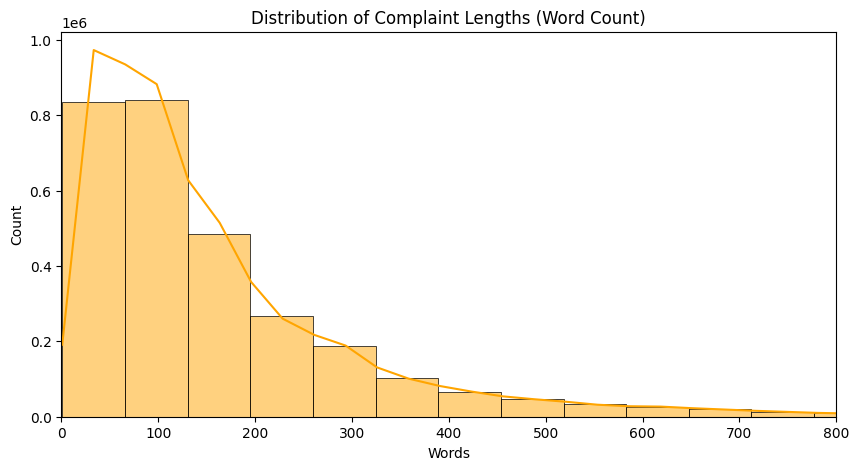

Average words per complaint: 176


In [9]:
# Length Analysis (Task: Visualize narrative word count)
# Filter out empty ones first
df_text = df[df['Consumer complaint narrative'].notna()].copy()
df_text['word_count'] = df_text['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_text['word_count'], bins=100, kde=True, color='orange')
plt.xlim(0, 800)  # Zooming in to see the most common lengths
plt.title('Distribution of Complaint Lengths (Word Count)')
plt.xlabel('Words')
plt.show()

print(f"Average words per complaint: {df_text['word_count'].mean():.0f}")

In [10]:
#  Filtering and Cleaning (Task: Filter for 4 products and clean text)
# 1. Filter for CrediTrust specific products
target_map = {
    'Credit card or prepaid card': 'Credit Card',
    'Credit card': 'Credit Card',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Consumer Loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Savings account': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer'
}

df_filtered = df[df['Product'].isin(target_map.keys())].copy()
df_filtered['product_category'] = df_filtered['Product'].map(target_map)
df_filtered = df_filtered[df_filtered['Consumer complaint narrative'].notna()]

# 2. Cleaning Function
def clean_text(text):
    text = text.lower()
    # Remove boilerplate as requested
    text = re.sub(r'i am writing to file a complaint regarding|to whom it may concern', '', text)
    # Remove special characters and XXXX masks
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'x{2,}', '', text)
    return " ".join(text.split())

df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].apply(clean_text)

print(f"Records after filtering: {len(df_filtered)}")
df_filtered[['product_category', 'cleaned_narrative']].head()

Records after filtering: 453540


,product_category,cleaned_narrative
12237,Credit Card,a card was opened under my name by a fraudster...
12532,Savings Account,i made the mistake of using my wellsfargo debi...
13280,Credit Card,dear cfpb i have a secured credit card with ci...
13506,Credit Card,i have a citi rewards cards the credit balance...
13955,Credit Card,bi am writing to dispute the following charges...


In [11]:
# Comparison (Check "Before vs After")
sample_index = 0
print("--- ORIGINAL ---")
print(df_filtered['Consumer complaint narrative'].iloc[sample_index][:300])
print("\n--- CLEANED ---")
print(df_filtered['cleaned_narrative'].iloc[sample_index][:300])

--- ORIGINAL ---
A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However

--- CLEANED ---
a card was opened under my name by a fraudster i received a notice from that an account was just opened under my name i reached out to to state that this activity was unauthorized and not me confirmed this was fraudulent and immediately closed the card however they have failed to remove this from th


In [12]:
# Save Cleaned Data
df_filtered.to_csv('../data/processed/filtered_complaints.csv', index=False)
print("Data saved to data/processed/filtered_complaints.csv")

Data saved to data/processed/filtered_complaints.csv
